<div align="center">
  <h2>Міністерство освіти і науки України</h2>
  <h2>Національний технічний університет України</h2>
  <h2>«Київський політехнічний інститут ім. Ігоря Сікорського»</h2>
  <h2>Факультет інформатики та обчислювальної техніки</h2>
  <h2>Кафедра обчислювальної техніки</h2>
  <br>
</div>

<div align="right">
    <br>
    <br>
<center>
<h2>Комп'ютерний практикум №2</h2>
    <h2>з дисципліни</h2>
    <h2>«Штучний інтелект в задачах обробки зображень»</h2>
    <h2>на тему:</h2>
    <h2>«Виявлення об’єктів засобами OpenCV»</h2>
</center>
    <br>
    <br>
    <br>
    <br>
    <br>
    <br>
    <br>
    <br>
Виконали: <br>
Студенти ІІІ курсу ФІОТ <br>
групи ІО-34 <br>
Токарюк С. Б., Рибачок М. В.<br>

<center>
Київ - 2026
</center>

## 1. Мета роботи
### Навчитись виявляти обличчя, котячі мордашки та пішоходів з використанням каскадів Хаара бібліотеки OpenCV

## 2. Програма роботи
1. Налаштування середовища: встановлення бібліотек та завантаження моделей.
2. Виявлення обличчя на фото
3. Виявлення багатьох облич на фото
4. Виявлення обличчя, усмішки, очей людей
5. Розпізнавання котячих мордашок
6. Виявлення пішоходів на відео (HOG-класифікатор)
7. Розпізнавання статі та емоцій людей


## 3. Теоретичні відомості
### 1. Метод каскадів Хаара для детекції об'єктів
Каскади Хаара — це алгоритм, що базується на машинному навчанні та аналізі цифрових ознак. Суть методу полягає у використанні «ознак Хаара» — прямокутних масок, які обчислюють різницю між сумами інтенсивностей пікселів у світлих та темних областях. Завдяки структурі «каскаду», система швидко відсікає ділянки зображення, де об'єкт точно відсутній, і зосереджує обчислювальні ресурси на потенційно важливих зонах. Це дозволяє ефективно виявляти обличчя людей, очі або морди тварин навіть на слабких процесорах.
### 2. Дескриптор HOG та виявлення людей
Гістограма орієнтованих градієнтів (HOG) — це метод опису ознак об'єктів, який фокусується на їхній формі та контурах. Алгоритм розбиває зображення на невеликі клітинки, для кожної з яких обчислюється напрямок та величина градієнта яскравості. Сукупність цих напрямків формує гістограму, яка є стійкою до змін освітлення та колірної гами. У поєднанні з лінійним класифікатором (SVM), HOG є стандартом для детекції пішоходів, оскільки він ідеально описує характерний силует людського тіла.
### 3. Алгоритм Fisherfaces для розпізнавання ознак
FisherFaceRecognizer — це метод розпізнавання облич, що базується на лінійному дискримінантному аналізі (LDA). На відміну від простіших підходів, Fisherfaces намагається знайти такі ознаки, які максимально розрізняють різні класи (наприклад, різні емоції або стать) і мінімізують відмінності всередині одного класу. Це робить модель стійкою до зовнішніх шумів, як-от зміна освітлення чи фону, дозволяючи точніше класифікувати емоційні стани (радість, гнів, нейтральність) та гендерні ознаки.
### 4. Попередня обробка зображень та нормалізація
Попередня обробка є критичним етапом перед запуском алгоритмів детекції та розпізнавання. Для стабільної роботи класифікаторів зображення обов'язково переводяться у градації сірого (grayscale), що зменшує обчислювальну складність з трьох каналів кольору до одного. Також застосовується зміна розміру (scaling) до фіксованих параметрів (наприклад, $350 \times 350$ пікселів), щоб вхідні дані відповідали архітектурі навченої моделі та забезпечували коректне порівняння ознак.

## 4. Виконання роботи

In [6]:
!pip install opencv-contrib-python deepface matplotlib os

  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl (46.5 MB)


ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os
You should consider upgrading via the 'c:\users\stas\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


In [1]:
# Завантаження потрібних бібліотек
import cv2, os
from deepface import DeepFace
import matplotlib.pyplot as plt

In [2]:
# Функція для відображення зображень у Jupyter
def show_img(img, title="Image"):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(title)
    plt.show()

In [3]:
# Ініціалізація основного класифікатора для облич
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

### 1. Виявлення обличчя на фото
Алгоритм Віоли-Джонса розроблявся для виявлення облич на фото.

Знайдено осіб: 1


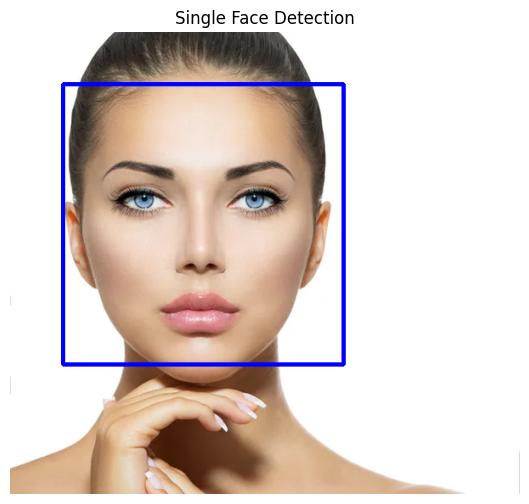

In [4]:
# Читання зображення (тут має бути фото з одним обличчям)
img_single = cv2.imread('photos/singlePhoto.jpg')
gray_single = cv2.cvtColor(img_single, cv2.COLOR_BGR2GRAY)

# Виявлення облич
faces_single = face_cascade.detectMultiScale(gray_single, scaleFactor=1.3, minNeighbors=5)

print(f"Знайдено осіб: {len(faces_single)}")

for (x, y, w, h) in faces_single:
    cv2.rectangle(img_single, (x, y), (x+w, y+h), (255, 0, 0), 3)

show_img(img_single, "Single Face Detection")

### 2. Виявлення багатьох облич на фото
Цей класифікатор може виявити також і багато облич на фото і підрахувати їх кількість.

Кількість знайдених осіб на фото: 23


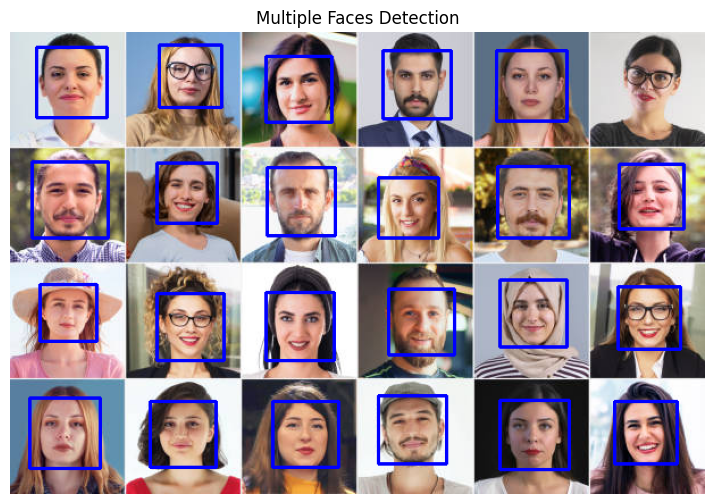

In [5]:
# Читання групового фото
img_multi = cv2.imread('photos/groupPhoto.jpg')
gray_multi = cv2.cvtColor(img_multi, cv2.COLOR_BGR2GRAY)

# Для багатьох облич іноді потрібно підкрутити параметри
faces_multi = face_cascade.detectMultiScale(gray_multi, scaleFactor=1.1, minNeighbors=5)

print(f"Кількість знайдених осіб на фото: {len(faces_multi)}")

for (x, y, w, h) in faces_multi:
    cv2.rectangle(img_multi, (x, y), (x+w, y+h), (255, 0, 0), 2)

show_img(img_multi, "Multiple Faces Detection")

### 3. Виявлення обличчя, усмішки, очей людей
Це завдання виконує виявлення ключових рис обличчя за допомогою класифікаторів Хаара.

Знайдено осіб: 1


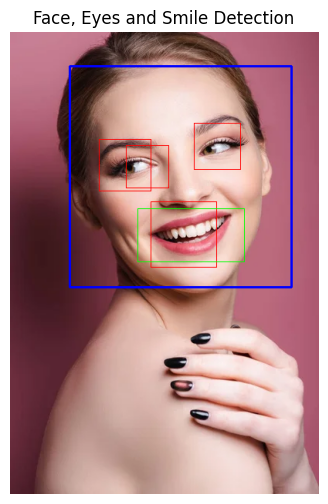

In [6]:
# Завантаження додаткових каскадів
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

# Читання зображення для детального аналізу
img_features = cv2.imread('photos/Photo3FaceSmiling.jpg')
# img_features = cv2.imread('photos/myPhoto.jpg')
# img_features = cv2.imread('photos/myPhoto0.jpg')
# img_features = cv2.imread('photos/myPhoto2.jpg.jpg')

gray_features = cv2.cvtColor(img_features, cv2.COLOR_BGR2GRAY)

faces_features = face_cascade.detectMultiScale(gray_features, 1.1, 5)

print(f"Знайдено осіб: {len(faces_features)}")

for (x, y, w, h) in faces_features:
    # Малюємо синій прямокутник навколо обличчя
    cv2.rectangle(img_features, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Вирізаємо область обличчя для подальшого пошуку в ній
    roi_gray = gray_features[y:y+h, x:x+w]
    roi_color = img_features[y:y+h, x:x+w]

    # Виявлення очей
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 0, 255), 1)

    # Виявлення усмішки
    smiles = smile_cascade.detectMultiScale(roi_gray, 1.4, 20)
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 1)

show_img(img_features, "Face, Eyes and Smile Detection")

### 4. Розпізнавання котячих мордашок:

Знайдено котиків: 3


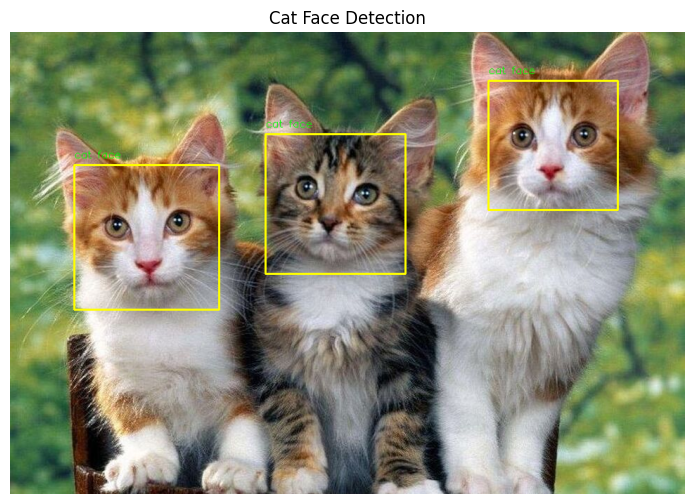

In [7]:
cat_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalcatface.xml'
)

# Завантаження зображення
img = cv2.imread('photos/catsPhoto.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Виявлення котячих мордочок
faces = cat_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=7)
print(f"Знайдено котиків: {len(faces)}")

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)
    cv2.putText(img, "cat face", (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

show_img(img, "Cat Face Detection")

### 5. Виявлення пішоходів на відео (HOG-класифікатор)
Використовуємо гістограму орієнтованих градієнтів (HOG) для детекції людей.

In [10]:
# Ініціалізація HOG детектора
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Відкриття відео (замініть на ваше відео або 0 для веб-камери)
cap = cv2.VideoCapture('video/peopleWalkingVideo.mp4')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break

    frame = cv2.resize(frame, (800, 568))

    # Детекція людей
    boxes, weights = hog.detectMultiScale(frame, winStride=(8, 8), padding=(30, 30), scale=1.06)

    for (x, y, w, h) in boxes:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

    cv2.imshow('Pedestrian Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

### 6. Розпізнавання статі та емоцій людей:

In [13]:
emotions = {
    0: "afraid",
    1: "angry",
    2: "disgusted",
    3: "happy",
    4: "neutral",
    5: "sad",
    6: "surprised"
}

# Для статі: 0 = female, 1 = male 
genders = {
    0: "female",
    1: "male"
}

def detect_faces(img):
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray,scaleFactor=1.1,minNeighbors=5)
    return faces

def resize_face(face):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    face = cv2.resize(face, (350, 350))
    return face

EMOTION_MODEL = 'models/emotion_classifier_model.xml'
GENDER_MODEL  = 'models/gender_classifier_model.xml'
IMAGE_PATH    = 'photos/Photo3FaceSmiling.jpg'

# Перевірка наявності 
if not os.path.exists(EMOTION_MODEL):
    print(f"Помилка: модель емоцій не знайдена → {EMOTION_MODEL}")
    exit()

if not os.path.exists(GENDER_MODEL):
    print(f"Помилка: модель статі не знайдена → {GENDER_MODEL}")
    exit()

# Завантаження моделей
emotion_recognizer = cv2.face.FisherFaceRecognizer_create()
emotion_recognizer.read(EMOTION_MODEL)

gender_recognizer = cv2.face.FisherFaceRecognizer_create()
gender_recognizer.read(GENDER_MODEL)

# Завантаження зображення
image = cv2.imread(IMAGE_PATH)

if image is None:
    print(f"Помилка: зображення не знайдено → {IMAGE_PATH}")
    exit()

# Знаходження облич на зображенні
faces = detect_faces(image)
print(f"Знайдено осіб: {len(faces)}")

for face in faces:
    (x, y, w, h) = face

    # Малювання прямокутника навколо обличчя
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 255), 2)

    # Виділення області обличчя
    roi_face = image[y:y + h, x:x + w]
    prepared = resize_face(roi_face)

    try:
        # Розпізнавання емоції
        predicted_emotion, confidence_e = emotion_recognizer.predict(prepared)
        emotion = emotions.get(predicted_emotion, "unknown")
        print(f"emotion: {emotion} (індекс {predicted_emotion}, впевненість: {confidence_e:.1f})")
        text = emotion

        # Розпізнавання статі
        predicted_gender, confidence_g = gender_recognizer.predict(prepared)
        gender = genders.get(predicted_gender, "unknown")
        print(f"gender:  {gender}  (індекс {predicted_gender}, впевненість: {confidence_g:.1f})")
        text += ", " + gender

    except Exception as e:
        print(f"Помилка розпізнавання: {e}")
        text = "error"

    # Виведення тексту на зображенні
    cv2.putText(image, text, (x, y - 10),
    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

# Відображення результату
cv2.imshow("Image", image)

cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.waitKey(1)

Знайдено осіб: 1
emotion: neutral (індекс 4, впевненість: 387.9)
gender:  female  (індекс 0, впевненість: 46.0)


-1

## Висновок:
 У ході виконання роботи було практично опановано методи детекції та класифікації об’єктів засобами бібліотеки OpenCV. Реалізовано системи виявлення об’єктів на базі каскадів Хаара та дескриптора HOG, а також проведено аналіз емоцій та статі з використанням моделей FisherFace. Експериментально встановлено, що ефективність детекції безпосередньо залежить від ракурсу зйомки та якості попередньої обробки даних - нормалізації розміру та конвертації зображень у градації сірого. 

#### Підготували: Рибачок Махайло та Токарюк Станіслав